In [1]:
import numpy as np
import matplotlib.pyplot as plt
import gaussian_beams as gb

In [2]:
wl = 532e-9 # wavelength in m

Fiber Mode Launched to the System

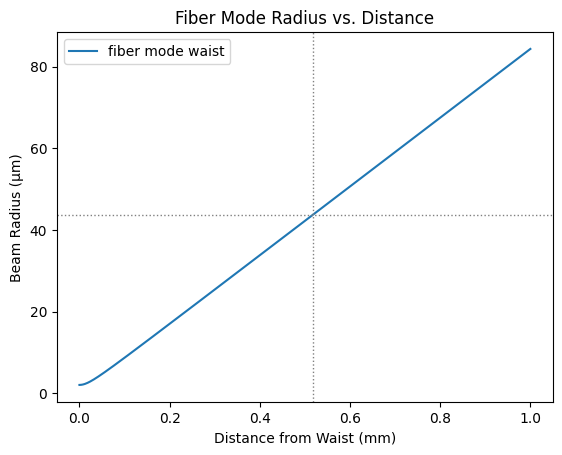

Rayleigh range (fiber mode): 23.81 μm
Beam radius = 43.64 μm at z = 517.03 μm


In [3]:
w0f = 2.008e-6 # fiber mode waist in m

z = np.linspace(0, 1e-3, 500) # distance from beam waist in m
z_mm = z * 1e3  # convert to mm

r = gb.beam_rad(wl, w0f, z)
r_um = r * 1e6

# target_um = 33.0 # based on the beam size at MEMS mirrors
target_um = 43.64 # based on the beam size at MEMS mirrors
idx = np.argmin(np.abs(r_um - target_um))
z_cross = z_mm[idx]

plt.plot(z_mm, r_um, label='fiber mode waist')
plt.axvline(z_cross, color='grey', linestyle=':', linewidth=1)
plt.axhline(target_um, color='grey', linestyle=':', linewidth=1)
plt.xlabel('Distance from Waist (mm)')
plt.ylabel('Beam Radius (μm)')
plt.title('Fiber Mode Radius vs. Distance')
plt.legend()
plt.show()

zR_f_um = gb.rayleigh_range(wl, w0f) * 1e6
print(f"Rayleigh range (fiber mode): {zR_f_um:.2f} μm")
print(f"Beam radius = {target_um:.2f} μm at z = {z_cross * 1e3:.2f} μm")

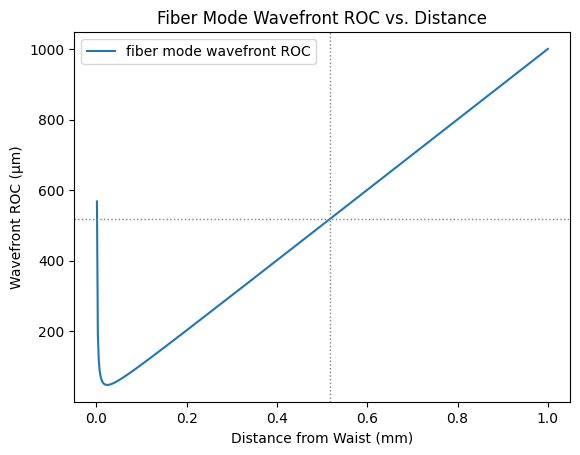

At z = 517.03 μm, wavefront ROC = 518.61 μm


In [4]:
z = np.linspace(1e-6, 1e-3, 500) # distance from beam waist in m
z_mm = z * 1e3  # convert to mm

roc = gb.wavefront_roc(wl, w0f, z)
roc_um = roc * 1e6

# z_target_um = 390.78
z_target_um = 517.03
z_lens1_um = z_target_um  # z-position of metalens 1 (used by Total Beam Propagation)
idx = np.argmin(np.abs(z * 1e6 - z_target_um))
roc_at_target = roc_um[idx]

plt.plot(z_mm, roc_um, label='fiber mode wavefront ROC')
plt.axvline(z_target_um / 1e3, color='grey', linestyle=':', linewidth=1)
plt.axhline(roc_at_target, color='grey', linestyle=':', linewidth=1)
plt.xlabel('Distance from Waist (mm)')
plt.ylabel('Wavefront ROC (μm)')
plt.title('Fiber Mode Wavefront ROC vs. Distance')
plt.legend()
plt.show()

print(f"At z = {z_target_um:.2f} μm, wavefront ROC = {roc_at_target:.2f} μm")

In [5]:
# Critical Parameters
print(f"Fiber mode waist (w0f): {w0f * 1e6:.3f} μm")
print(f"At z = {z_target_um:.2f} μm, the beam radius is {target_um:.2f} μm and the wavefront ROC is {roc_at_target:.2f} μm")

Fiber mode waist (w0f): 2.008 μm
At z = 517.03 μm, the beam radius is 43.64 μm and the wavefront ROC is 518.61 μm


Elliptical Beam Projected onto MEMS Mirror

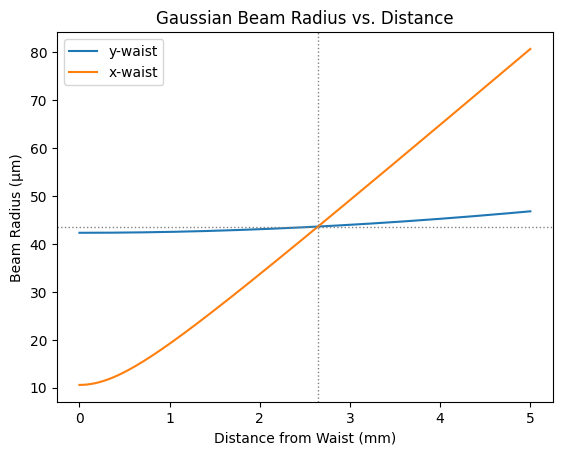

Rayleigh range (w0y): 10586.20 μm
Rayleigh range (w0x): 661.01 μm
Intersection: z = 2645.29 μm, beam radius = 43.64 μm


In [6]:
# w0y = 32e-6 # beam waist y in m
# w0x = 8e-6 # beam waist x in m
w0y = 42.34e-6 # beam waist y in m
w0x = 10.58e-6 # beam waist x in m

z = np.linspace(0, 5e-3, 500) # distance from beam waist in m
z_mm = z * 1e3  # convert to mm

ry = gb.beam_rad(wl, w0y, z)
rx = gb.beam_rad(wl, w0x, z)

diff = ry - rx
idx = np.argmin(np.abs(diff))
z_int = z_mm[idx]
r_int = (ry[idx] + rx[idx]) / 2 * 1e6

plt.plot(z_mm, ry * 1e6, label='y-waist')
plt.plot(z_mm, rx * 1e6, label='x-waist')
plt.axvline(z_int, color='grey', linestyle=':', linewidth=1)
plt.axhline(r_int, color='grey', linestyle=':', linewidth=1)
plt.xlabel('Distance from Waist (mm)')
plt.ylabel('Beam Radius (μm)')
plt.title('Gaussian Beam Radius vs. Distance')
plt.legend()
plt.show()

zR_y_um = gb.rayleigh_range(wl, w0y) * 1e6
zR_x_um = gb.rayleigh_range(wl, w0x) * 1e6
print(f"Rayleigh range (w0y): {zR_y_um:.2f} μm")
print(f"Rayleigh range (w0x): {zR_x_um:.2f} μm")

print(f"Intersection: z = {z_int * 1e3:.2f} μm, beam radius = {r_int:.2f} μm")

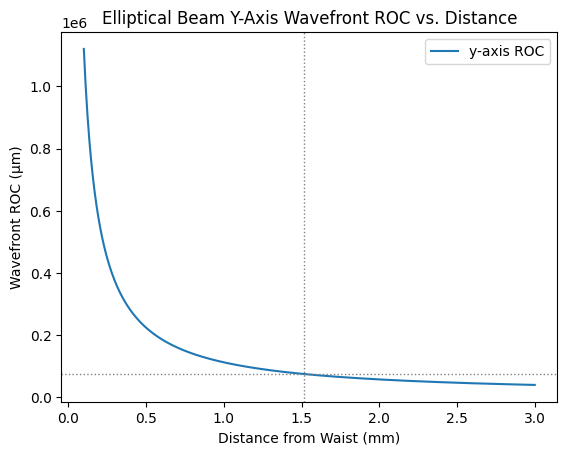

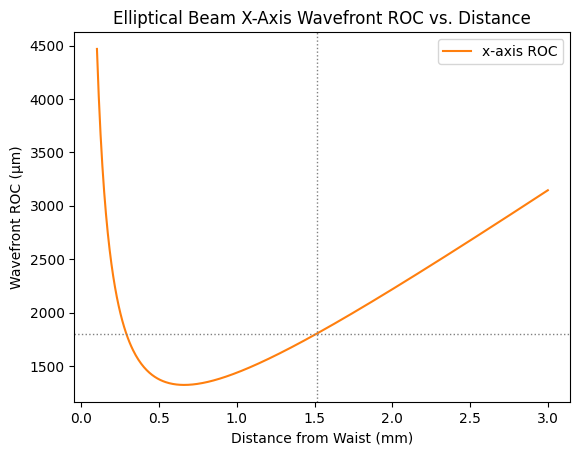

At z = 1513.03 μm: y-axis ROC = 75619.98 μm, x-axis ROC = 1801.16 μm


In [7]:
z = np.linspace(1e-4, 3e-3, 500)

roc_y = gb.wavefront_roc(wl, w0y, z) * 1e6
roc_x = gb.wavefront_roc(wl, w0x, z) * 1e6

z_target_um = 1513.03
idx = np.argmin(np.abs(z * 1e6 - z_target_um))
roc_y_at_target = roc_y[idx]
roc_x_at_target = roc_x[idx]

plt.plot(z * 1e3, roc_y, label='y-axis ROC')
plt.axvline(z_target_um / 1e3, color='grey', linestyle=':', linewidth=1)
plt.axhline(roc_y_at_target, color='grey', linestyle=':', linewidth=1)
plt.xlabel('Distance from Waist (mm)')
plt.ylabel('Wavefront ROC (μm)')
plt.title('Elliptical Beam Y-Axis Wavefront ROC vs. Distance')
plt.legend()
plt.show()

plt.plot(z * 1e3, roc_x, color='C1', label='x-axis ROC')
plt.axvline(z_target_um / 1e3, color='grey', linestyle=':', linewidth=1)
plt.axhline(roc_x_at_target, color='grey', linestyle=':', linewidth=1)
plt.xlabel('Distance from Waist (mm)')
plt.ylabel('Wavefront ROC (μm)')
plt.title('Elliptical Beam X-Axis Wavefront ROC vs. Distance')
plt.legend()
plt.show()

print(f"At z = {z_target_um:.2f} μm: y-axis ROC = {roc_y_at_target:.2f} μm, x-axis ROC = {roc_x_at_target:.2f} μm")

In [8]:
# Critical Parameters
ry_at_target = gb.beam_rad(wl, w0y, z_target_um * 1e-6) * 1e6
rx_at_target = gb.beam_rad(wl, w0x, z_target_um * 1e-6) * 1e6

print(f"Y-Axis")
print(f"Beam waist (w0y):         {w0y * 1e6:.2f} μm")
print(f"Rayleigh range:           {zR_y_um:.2f} μm")
print(f"Beam radius at z = {z_target_um:.2f} μm:  {ry_at_target:.2f} μm")
print(f"Wavefront ROC at z = {z_target_um:.2f} μm: {roc_y_at_target:.2f} μm")
print()
print(f"X-Axis")
print(f"Beam waist (w0x):         {w0x * 1e6:.2f} μm")
print(f"Rayleigh range:           {zR_x_um:.2f} μm")
print(f"Beam radius at z = {z_target_um:.2f} μm:  {rx_at_target:.2f} μm")
print(f"Wavefront ROC at z = {z_target_um:.2f} μm: {roc_x_at_target:.2f} μm")
print()
print(f"Both Axes")
print(f"Beam radius intersection: z = {z_int * 1e3:.2f} μm, r = {r_int:.2f} μm")

Y-Axis
Beam waist (w0y):         42.34 μm
Rayleigh range:           10586.20 μm
Beam radius at z = 1513.03 μm:  42.77 μm
Wavefront ROC at z = 1513.03 μm: 75619.98 μm

X-Axis
Beam waist (w0x):         10.58 μm
Rayleigh range:           661.01 μm
Beam radius at z = 1513.03 μm:  26.43 μm
Wavefront ROC at z = 1513.03 μm: 1801.16 μm

Both Axes
Beam radius intersection: z = 2645.29 μm, r = 43.64 μm


Focused Elliptical Beam for Individual Addressing

In [9]:
# w0yf = 2e-6   # target focused waist y in m
# w0xf = 8e-6   # target focused waist x in m

# # With z1=f, w0_transf reduces to: w0' = w0*f / zR
# # Solving for f: f = w0' * zR / w0
# zR_y = gb.rayleigh_range(wl, w0y)
# zR_x = gb.rayleigh_range(wl, w0x)
# f_y = w0yf * zR_y / w0y
# f_x = w0xf * zR_x / w0x

# print(f"f for y-axis: {f_y * 1e6:.3f} μm")
# print(f"f for x-axis: {f_x * 1e6:.3f} μm")

# # Verify
# w0y_prime = gb.w0_transf(wl, w0y, f_y, f_y)
# w0x_prime = gb.w0_transf(wl, w0x, f_x, f_x)
# print(f"Verification: w0y_prime = {w0y_prime * 1e6:.2f} μm (target: {w0yf * 1e6:.2f} μm)")
# print(f"Verification: w0x_prime = {w0x_prime * 1e6:.2f} μm (target: {w0xf * 1e6:.2f} μm)")

In [10]:
w0yf = 2e-6   # target focused waist y in m
w0xf = 8e-6   # target focused waist x in m

f = 500.0e-6 # edmund optics off the shelf metalens 86-933

# With z1=f, w0_transf reduces to: w0' = w0*f / zR
# Solving for f: f = w0' * zR / w0
w0y_1 = f * wl / (np.pi * w0yf)
w0x_1 = f * wl / (np.pi * w0xf)

# Verify
print(f"Y Waist at MEMS = {w0y_1 * 1e6:.2f} μm (target: {w0y * 1e6:.2f} μm)")
print(f"X Waist at MEMS = {w0x_1 * 1e6:.2f} μm (target: {w0x * 1e6:.2f} μm)")
w0y_prime = gb.w0_transf(wl, w0y_1, f, f)
w0x_prime = gb.w0_transf(wl, w0x_1, f, f)
print(f"Verification: w0y_prime = {w0y_prime * 1e6:.2f} μm (target: {w0yf * 1e6:.2f} μm)")
print(f"Verification: w0x_prime = {w0x_prime * 1e6:.2f} μm (target: {w0xf * 1e6:.2f} μm)")

Y Waist at MEMS = 42.34 μm (target: 42.34 μm)
X Waist at MEMS = 10.58 μm (target: 10.58 μm)
Verification: w0y_prime = 2.00 μm (target: 2.00 μm)
Verification: w0x_prime = 8.00 μm (target: 8.00 μm)


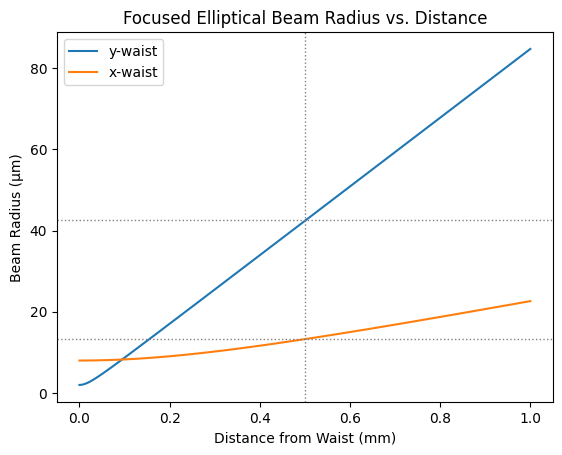

Rayleigh range (w0yf): 23.62 μm
Rayleigh range (w0xf): 377.94 μm
At z = f = 500.00 μm: y-radius = 42.47 μm, x-radius = 13.28 μm


In [11]:
z = np.linspace(0, 1e-3, 500) # distance from beam waist in m
z_mm = z * 1e3  # convert to mm

ryf = gb.beam_rad(wl, w0yf, z)
rxf = gb.beam_rad(wl, w0xf, z)

# f = 377.936e-6  # focal length in m
f = 500.0e-6 # edmund optics off the shelf metalens 86-933
f_um = f * 1e6 # focal length in μm
idx_f = np.argmin(np.abs(z * 1e6 - f_um))
ryf_at_f = ryf[idx_f] * 1e6
rxf_at_f = rxf[idx_f] * 1e6

plt.plot(z_mm, ryf * 1e6, label='y-waist')
plt.plot(z_mm, rxf * 1e6, label='x-waist')
plt.axvline(f_um / 1e3, color='grey', linestyle=':', linewidth=1)
plt.axhline(ryf_at_f, color='grey', linestyle=':', linewidth=1)
plt.axhline(rxf_at_f, color='grey', linestyle=':', linewidth=1)
plt.xlabel('Distance from Waist (mm)')
plt.ylabel('Beam Radius (μm)')
plt.title('Focused Elliptical Beam Radius vs. Distance')
plt.legend()
plt.show()

zR_yf_um = gb.rayleigh_range(wl, w0yf) * 1e6
zR_xf_um = gb.rayleigh_range(wl, w0xf) * 1e6
print(f"Rayleigh range (w0yf): {zR_yf_um:.2f} μm")
print(f"Rayleigh range (w0xf): {zR_xf_um:.2f} μm")
print(f"At z = f = {f_um:.2f} μm: y-radius = {ryf_at_f:.2f} μm, x-radius = {rxf_at_f:.2f} μm")

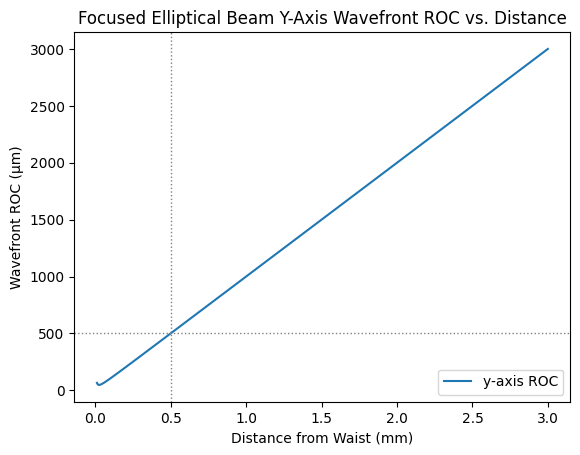

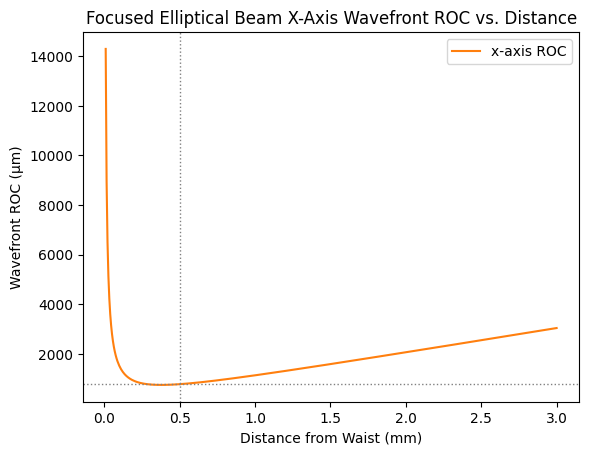

At z = f = 500.00 μm: y-axis ROC = 502.46 μm, x-axis ROC = 786.25 μm


In [12]:
z = np.linspace(1e-5, 3e-3, 500)

rocf_y = gb.wavefront_roc(wl, w0yf, z) * 1e6
rocf_x = gb.wavefront_roc(wl, w0xf, z) * 1e6

idx_f = np.argmin(np.abs(z * 1e6 - f_um))
rocf_y_at_f = rocf_y[idx_f]
rocf_x_at_f = rocf_x[idx_f]

plt.plot(z * 1e3, rocf_y, label='y-axis ROC')
plt.axvline(f_um / 1e3, color='grey', linestyle=':', linewidth=1)
plt.axhline(rocf_y_at_f, color='grey', linestyle=':', linewidth=1)
plt.xlabel('Distance from Waist (mm)')
plt.ylabel('Wavefront ROC (μm)')
plt.title('Focused Elliptical Beam Y-Axis Wavefront ROC vs. Distance')
plt.legend()
plt.show()

plt.plot(z * 1e3, rocf_x, color='C1', label='x-axis ROC')
plt.axvline(f_um / 1e3, color='grey', linestyle=':', linewidth=1)
plt.axhline(rocf_x_at_f, color='grey', linestyle=':', linewidth=1)
plt.xlabel('Distance from Waist (mm)')
plt.ylabel('Wavefront ROC (μm)')
plt.title('Focused Elliptical Beam X-Axis Wavefront ROC vs. Distance')
plt.legend()
plt.show()

print(f"At z = f = {f_um:.2f} μm: y-axis ROC = {rocf_y_at_f:.2f} μm, x-axis ROC = {rocf_x_at_f:.2f} μm")

Total Beam Propagation

In [13]:
# # Critical Parameters

# zR_y_ell_um = gb.rayleigh_range(wl, w0y) * 1e6
# zR_x_ell_um = gb.rayleigh_range(wl, w0x) * 1e6

# # Beam radii at metalens 2 (elliptical beam, z=f from ell waist)
# ry_at_ml2 = gb.beam_rad(wl, w0y, f) * 1e6
# rx_at_ml2 = gb.beam_rad(wl, w0x, f) * 1e6

# # ROC at each lens surface
# roc_before_ml1   = gb.wavefront_roc(wl, w0f,  z_lens1) * 1e6
# roc_after_ml1_y  = gb.wavefront_roc(wl, w0y,  -z_post_end) * 1e6
# roc_after_ml1_x  = gb.wavefront_roc(wl, w0x,  -z_post_end) * 1e6
# roc_before_ml2_y = gb.wavefront_roc(wl, w0y,   f) * 1e6
# roc_before_ml2_x = gb.wavefront_roc(wl, w0x,   f) * 1e6
# roc_after_ml2_y  = gb.wavefront_roc(wl, w0yf, -f) * 1e6
# roc_after_ml2_x  = gb.wavefront_roc(wl, w0xf, -f) * 1e6

# W = 40

# print('Fiber Mode')
# print(f"  {'Waist (w0f)':<{W}} {w0f * 1e6:.2f} um")
# print(f"  {'Rayleigh range':<{W}} {zR_f_um:.2f} um")
# print(f"  {'Beam radius at metalens 1':<{W}} {target_um:.2f} um")
# print()
# print('Elliptical Beam (MEMS Mirror)')
# print(f"  {'x Beam radius at metalens 1':<{W}} {rx_at_target:.2f} um")
# print(f"  {'x Waist (at MEMS mirror)':<{W}} {w0x * 1e6:.2f} um")
# print(f"  {'x Rayleigh range':<{W}} {zR_x_ell_um:.2f} um")
# print(f"  {'x Beam radius at metalens 2':<{W}} {rx_at_ml2:.2f} um")
# print(f"  {'y Beam radius at metalens 1':<{W}} {ry_at_target:.2f} um")
# print(f"  {'y Waist (at MEMS mirror)':<{W}} {w0y * 1e6:.2f} um")
# print(f"  {'y Rayleigh range':<{W}} {zR_y_ell_um:.2f} um")
# print(f"  {'y Beam radius at metalens 2':<{W}} {ry_at_ml2:.2f} um")
# print()
# print('Focused Elliptical Beam')
# print(f"  {'Focal length (f)':<{W}} {f * 1e6:.3f} um")
# print(f"  {'x Beam radius at metalens 2 (z=f)':<{W}} {rxf_at_f:.2f} um")
# print(f"  {'x Focused waist':<{W}} {w0xf * 1e6:.2f} um")
# print(f"  {'x Rayleigh range':<{W}} {zR_xf_um:.2f} um")
# print(f"  {'y Beam radius at metalens 2 (z=f)':<{W}} {ryf_at_f:.2f} um")
# print(f"  {'y Focused waist':<{W}} {w0yf * 1e6:.2f} um")
# print(f"  {'y Rayleigh range':<{W}} {zR_yf_um:.2f} um")
# print()
# print('Global Propagation Positions')
# print(f"  {'Fiber mode waist (z)':<{W}} {0:.2f} um")
# print(f"  {'Metalens 1 (z)':<{W}} {z_lens1 * 1e6:.2f} um")
# print(f"  {'Elliptical beam waist (z)':<{W}} {z_ell_waist * 1e6:.2f} um")
# print(f"  {'Metalens 2 (z)':<{W}} {z_lens2 * 1e6:.2f} um")
# print(f"  {'Focused beam waist (z)':<{W}} {z_focused_waist * 1e6:.2f} um")
# print()
# print('Wavefront ROC at Lens Surfaces')
# print(f"  {'x-axis, Metalens 1 — before':<{W}} {roc_before_ml1:.2f} um")
# print(f"  {'x-axis, Metalens 1 — after  ':<{W}} {roc_after_ml1_x:.2f} um")
# print(f"  {'x-axis, Metalens 2 — before':<{W}} {roc_before_ml2_x:.2f} um")
# print(f"  {'x-axis, Metalens 2 — after  ':<{W}} {roc_after_ml2_x:.2f} um")
# print(f"  {'y-axis, Metalens 1 — before':<{W}} {roc_before_ml1:.2f} um")
# print(f"  {'y-axis, Metalens 1 — after  ':<{W}} {roc_after_ml1_y:.2f} um")
# print(f"  {'y-axis, Metalens 2 — before':<{W}} {roc_before_ml2_y:.2f} um")
# print(f"  {'y-axis, Metalens 2 — after  ':<{W}} {roc_after_ml2_y:.2f} um")

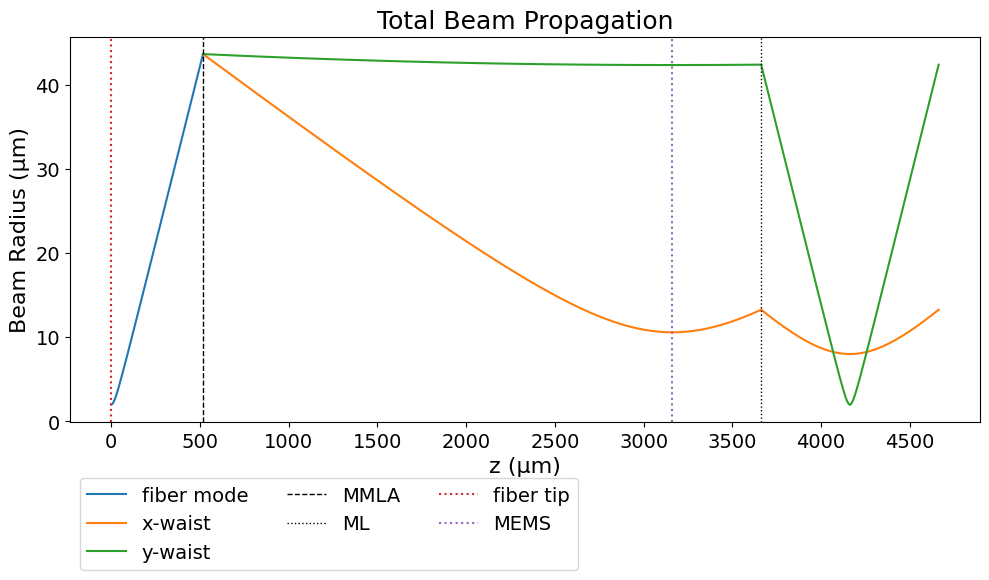

Global z Positions (from fiber tip)
  Metalens 1                 517.03 μm   ( 0.5170 mm)
  MEMS mirror               3162.32 μm   ( 3.1623 mm)
  Metalens 2                3662.32 μm   ( 3.6623 mm)
  Final waist               4162.32 μm   ( 4.1623 mm)


In [14]:
from matplotlib.ticker import MultipleLocator

# Global z positions (m)
z_lens1 = z_lens1_um * 1e-6          # metalens 1 position (from fiber ROC target cell)
z_post_end = z_int * 1e-3            # metalens 1 -> elliptical waist: x/y radius intersection (r = 43.64 um, matches fiber r at ml1)
z_ell_waist = z_lens1 + z_post_end
z_lens2 = z_ell_waist + f
z_focused_waist = z_lens2 + f

N = 300

# Seg 1: fiber expanding to lens 1
z1 = np.linspace(1e-9, z_lens1, N)
r1 = gb.beam_rad(wl, w0f, z1) * 1e6

# Seg 2: elliptical beam converging to its waist (lens 1 to ell waist)
z2_local = np.linspace(-z_post_end, 0, N)
rx2 = gb.beam_rad(wl, w0x, z2_local) * 1e6
ry2 = gb.beam_rad(wl, w0y, z2_local) * 1e6
z2_um = (z_ell_waist + z2_local) * 1e6

# Seg 3: elliptical beam diverging from waist to lens 2
z3_local = np.linspace(0, f, N)
rx3 = gb.beam_rad(wl, w0x, z3_local) * 1e6
ry3 = gb.beam_rad(wl, w0y, z3_local) * 1e6
z3_um = (z_ell_waist + z3_local) * 1e6

# Seg 4: focused beam converging from lens 2 to focused waist
z4_local = np.linspace(-f, 0, N)
rxf4 = gb.beam_rad(wl, w0xf, z4_local) * 1e6
ryf4 = gb.beam_rad(wl, w0yf, z4_local) * 1e6
z4_um = (z_focused_waist + z4_local) * 1e6

# Seg 5: focused beam diverging after focused waist
z5_local = np.linspace(0, f, N)
rxf5 = gb.beam_rad(wl, w0xf, z5_local) * 1e6
ryf5 = gb.beam_rad(wl, w0yf, z5_local) * 1e6
z5_um = (z_focused_waist + z5_local) * 1e6

plt.figure(figsize=(10, 6))
plt.plot(z1 * 1e6, r1, color='C0', label='fiber mode')
plt.plot(z2_um, rx2, color='C1', label='x-waist')
plt.plot(z2_um, ry2, color='C2', label='y-waist')
plt.plot(z3_um, rx3, color='C1')
plt.plot(z3_um, ry3, color='C2')
plt.plot(z4_um, rxf4, color='C1')
plt.plot(z4_um, ryf4, color='C2')
plt.plot(z5_um, rxf5, color='C1')
plt.plot(z5_um, ryf5, color='C2')
plt.axvline(z_lens1 * 1e6, color='black', linestyle='--', linewidth=1, label='MMLA')
plt.axvline(z_lens2 * 1e6, color='black', linestyle=':', linewidth=1, label='ML')
plt.axvline(0, color='C3', linestyle=':', linewidth=1.5, label='fiber tip')
plt.axvline(z_ell_waist * 1e6, color='C4', linestyle=':', linewidth=1.5, label='MEMS')
plt.xlabel('z (μm)', fontsize=16)
plt.ylabel('Beam Radius (μm)', fontsize=16)
plt.title('Total Beam Propagation', fontsize=18)
plt.legend(loc='upper left', bbox_to_anchor=(0.0, -0.12), ncol=3, fontsize=14)
plt.gca().xaxis.set_major_locator(MultipleLocator(500))  # x-axis tick every 500 um
plt.tick_params(labelsize=14)
plt.tight_layout()
plt.show()

# Global z positions (measured from the fiber tip at z = 0)
W = 22
print('Global z Positions (from fiber tip)')
print(f"  {'Metalens 1':<{W}} {z_lens1 * 1e6:>10.2f} μm   ({z_lens1 * 1e3:>7.4f} mm)")
print(f"  {'MEMS mirror':<{W}} {z_ell_waist * 1e6:>10.2f} μm   ({z_ell_waist * 1e3:>7.4f} mm)")
print(f"  {'Metalens 2':<{W}} {z_lens2 * 1e6:>10.2f} μm   ({z_lens2 * 1e3:>7.4f} mm)")
print(f"  {'Final waist':<{W}} {z_focused_waist * 1e6:>10.2f} μm   ({z_focused_waist * 1e3:>7.4f} mm)")

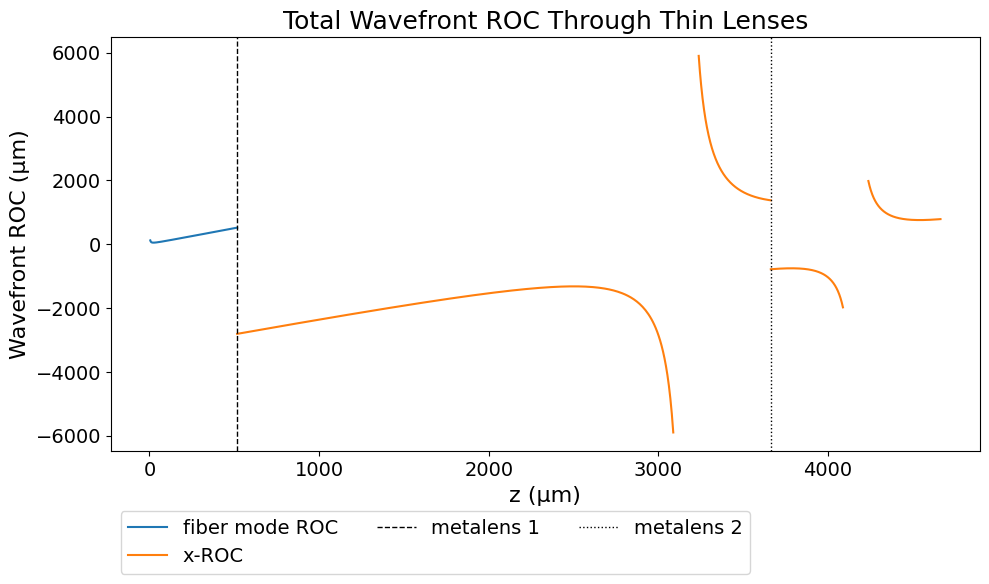

In [15]:
z_cut_fiber = 5e-6
z_cut_ell_x = 75e-6
z_cut_foc   = 75e-6

N = 300

z1 = np.linspace(z_cut_fiber, z_lens1, N)
roc1 = gb.wavefront_roc(wl, w0f, z1) * 1e6

z2_local = np.linspace(-z_post_end, -z_cut_ell_x, N)
roc_x2 = gb.wavefront_roc(wl, w0x, z2_local) * 1e6
z2_um = (z_ell_waist + z2_local) * 1e6

z3_local = np.linspace(z_cut_ell_x, f, N)
roc_x3 = gb.wavefront_roc(wl, w0x, z3_local) * 1e6
z3_um = (z_ell_waist + z3_local) * 1e6

z4_local = np.linspace(-f, -z_cut_foc, N)
roc_xf4 = gb.wavefront_roc(wl, w0xf, z4_local) * 1e6
z4_um = (z_focused_waist + z4_local) * 1e6

z5_local = np.linspace(z_cut_foc, f, N)
roc_xf5 = gb.wavefront_roc(wl, w0xf, z5_local) * 1e6
z5_um = (z_focused_waist + z5_local) * 1e6

plt.figure(figsize=(10, 6))
plt.plot(z1 * 1e6, roc1, color='C0', label='fiber mode ROC')
plt.plot(z2_um, roc_x2, color='C1', label='x-ROC')
plt.plot(z3_um, roc_x3, color='C1')
plt.plot(z4_um, roc_xf4, color='C1')
plt.plot(z5_um, roc_xf5, color='C1')
plt.axvline(z_lens1 * 1e6, color='black', linestyle='--', linewidth=1, label='metalens 1')
plt.axvline(z_lens2 * 1e6, color='black', linestyle=':', linewidth=1, label='metalens 2')
plt.xlabel('z (μm)', fontsize=16)
plt.ylabel('Wavefront ROC (μm)', fontsize=16)
plt.title('Total Wavefront ROC Through Thin Lenses', fontsize=18)
plt.legend(loc='upper left', bbox_to_anchor=(0.0, -0.12), ncol=3, fontsize=14)
plt.tick_params(labelsize=14)
plt.tight_layout()
plt.show()

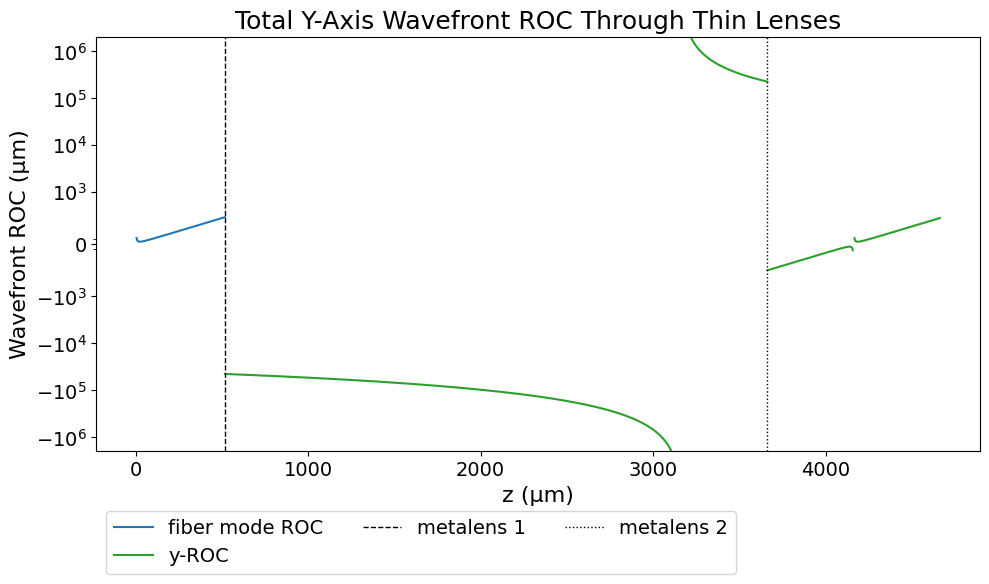

In [16]:
z_cut_fiber = 5e-6
z_cut_ell_y = 30e-6
z_cut_foc_y = 5e-6

N = 300

# Seg 1: fiber ROC
z1 = np.linspace(z_cut_fiber, z_lens1, N)
roc1 = gb.wavefront_roc(wl, w0f, z1) * 1e6

# Seg 2: elliptical y converging (negative ROC)
z2_local = np.linspace(-z_post_end, -z_cut_ell_y, N)
roc_y2 = gb.wavefront_roc(wl, w0y, z2_local) * 1e6
z2_um = (z_ell_waist + z2_local) * 1e6

# Seg 3: elliptical y diverging (positive ROC)
z3_local = np.linspace(z_cut_ell_y, f, N)
roc_y3 = gb.wavefront_roc(wl, w0y, z3_local) * 1e6
z3_um = (z_ell_waist + z3_local) * 1e6

# Seg 4: focused y converging (negative ROC)
z4_local = np.linspace(-f, -z_cut_foc_y, N)
roc_yf4 = gb.wavefront_roc(wl, w0yf, z4_local) * 1e6
z4_um = (z_focused_waist + z4_local) * 1e6

# Seg 5: focused y diverging (positive ROC)
z5_local = np.linspace(z_cut_foc_y, f, N)
roc_yf5 = gb.wavefront_roc(wl, w0yf, z5_local) * 1e6
z5_um = (z_focused_waist + z5_local) * 1e6

plt.figure(figsize=(10, 6))
plt.plot(z1 * 1e6, roc1, color='C0', label='fiber mode ROC')
plt.plot(z2_um, roc_y2, color='C2', label='y-ROC')
plt.plot(z3_um, roc_y3, color='C2')
plt.plot(z4_um, roc_yf4, color='C2')
plt.plot(z5_um, roc_yf5, color='C2')
plt.axvline(z_lens1 * 1e6, color='black', linestyle='--', linewidth=1, label='metalens 1')
plt.axvline(z_lens2 * 1e6, color='black', linestyle=':', linewidth=1, label='metalens 2')
plt.xlabel('z (μm)', fontsize=16)
plt.ylabel('Wavefront ROC (μm)', fontsize=16)
plt.title('Total Y-Axis Wavefront ROC Through Thin Lenses', fontsize=18)
plt.legend(loc='upper left', bbox_to_anchor=(0.0, -0.12), ncol=3, fontsize=14)
plt.yscale('symlog', linthresh=1000)
plt.ylim(-2e6, 2e6)
plt.yticks([-1e6, -1e5, -1e4, -1e3, 0, 1e3, 1e4, 1e5, 1e6])
plt.tick_params(labelsize=14)
plt.tight_layout()
plt.show()

Phase Profiles

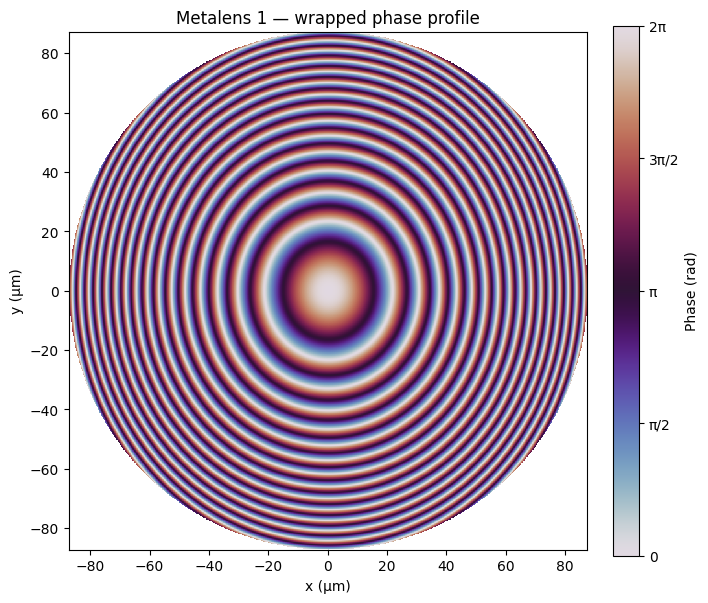

In [18]:
# Metalens 1
wl = 532e-9
k = 2 * np.pi / wl

w0_in = 2.008e-6
w0_out = np.array([10.58e-6, 42.34e-6])  # x, y

zR_in = np.pi * w0_in**2 / wl
zR_out = np.pi * w0_out**2 / wl

# Exact geometry for circular input and coincident elliptical waists
d = np.pi * np.prod(w0_out) / wl
w_ml = np.linalg.norm(w0_out)
s = zR_in * np.sqrt((w_ml / w0_in)**2 - 1)

# Signed inverse wavefront curvatures at the metalens
C_in = s / (s**2 + zR_in**2)
C_out = -d / (d**2 + zR_out**2)
delta_C = C_out - C_in

def metalens_phase(X, Y):
    """X and Y: coordinates in meters; returns phase in [0, 2*pi)."""
    phi = 0.5 * k * (delta_C[0] * X**2 + delta_C[1] * Y**2)
    return np.mod(phi, 2 * np.pi)

# Verify the resulting Gaussian reaches the requested waists
q_in = s + 1j * zR_in
q_after = 1 / (1 / q_in + delta_C)
q_at_target = q_after + d
assert np.allclose(q_at_target, 1j * zR_out, rtol=1e-10, atol=1e-15)


# Plot
aperture_radius = 2 * w_ml
N = 801

x = np.linspace(-aperture_radius, aperture_radius, N)
y = np.linspace(-aperture_radius, aperture_radius, N)
X, Y = np.meshgrid(x, y)

phase = metalens_phase(X, Y)
phase = np.ma.masked_where(
    X**2 + Y**2 > aperture_radius**2, phase
)

fig, ax = plt.subplots(figsize=(7, 6), constrained_layout=True)
im = ax.imshow(
    phase,
    extent=[x[0] * 1e6, x[-1] * 1e6, y[0] * 1e6, y[-1] * 1e6],
    origin="lower",
    cmap="twilight",  # Cyclic colormap for wrapped phase
    vmin=0,
    vmax=2 * np.pi,
    interpolation="nearest",
    aspect="equal",
)

cbar = fig.colorbar(im, ax=ax, label="Phase (rad)")
cbar.set_ticks(
    [0, np.pi / 2, np.pi, 3 * np.pi / 2, 2 * np.pi],
    labels=["0", "π/2", "π", "3π/2", "2π"],
)

ax.set(
    xlabel="x (μm)",
    ylabel="y (μm)",
    title="Metalens 1 — wrapped phase profile",
)
plt.show()

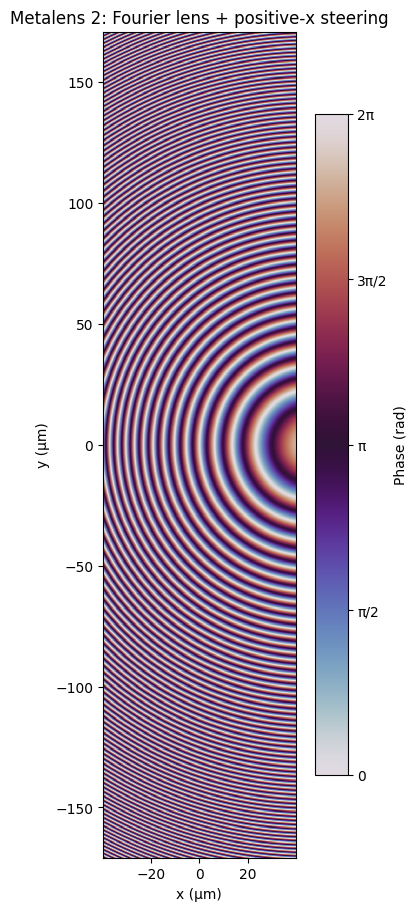

Target x displacement: 46.027 μm
Paraxial output tilt: 5.274 degrees
Ramp period: 5.779 μm
Target y scan: ±43.633 μm
Aperture x × y: 79.60 × 341.56 μm
Maximum ideal zero-order background: 1.000e-05


In [19]:
# Metalens 2
# All lengths in meters. Same exp(-i*omega*t) convention as before.
wl = 532e-9
k = 2 * np.pi / wl
f = 500e-6

theta_max = np.deg2rad(5.0)  # Optical angle, not mechanical mirror angle
epsilon = 1e-5              # Relative to zero-order peak intensity
margin = 3.0               # Aperture margin in Gaussian beam radii
aperture_shape = "rectangle"  # "rectangle" or "ellipse"

# Desired waist radii in the target plane: x, y
w_target = np.array([8e-6, 2e-6])

# Required MEMS waist radii for the f-to-f Fourier transform
w_mems = wl * f / (np.pi * w_target)
zR_mems = np.pi * w_mems**2 / wl

# Beam radii at lens and for the zero order at the target plane
w_lens = w_mems * np.sqrt(1 + (f / zR_mems)**2)
w_zero = w_mems * np.sqrt(1 + (2 * f / zR_mems)**2)

# Minimum lateral separation, set by the zero-scan case
dx_min = w_zero[0] * np.sqrt(np.log(1 / epsilon) / 2)
dx = dx_min                 # Increase this to add separation margin
alpha = dx / f              # Paraxial output tilt
ramp_period = wl / alpha

# Aperture accommodates beam walk in y
y_walk = f * theta_max
ax_rect = margin * w_lens[0]
ay_rect = y_walk + margin * w_lens[1]

if aperture_shape == "rectangle":
    ax, ay = ax_rect, ay_rect
elif aperture_shape == "ellipse":
    # This ellipse encloses the entire chosen rectangle.
    ax, ay = np.sqrt(2) * np.array([ax_rect, ay_rect])
else:
    raise ValueError("Choose 'rectangle' or 'ellipse'.")

# Plotting grid only; fabrication sampling uses the meta-atom lattice.
x = np.linspace(-ax, ax, 801)
y = np.linspace(-ay, ay, 1601)
X, Y = np.meshgrid(x, y)

phi_lens = -k * (X**2 + Y**2) / (2 * f)
phi_ramp = k * alpha * X
phase = np.mod(phi_lens + phi_ramp, 2 * np.pi)

if aperture_shape == "ellipse":
    inside = (X / ax)**2 + (Y / ay)**2 <= 1
else:
    inside = np.ones(X.shape, dtype=bool)

phase = np.ma.masked_where(~inside, phase)

fig, ax_plot = plt.subplots(figsize=(5, 9), constrained_layout=True)
im = ax_plot.imshow(
    phase,
    extent=[x[0]*1e6, x[-1]*1e6, y[0]*1e6, y[-1]*1e6],
    origin="lower",
    cmap="twilight",
    vmin=0,
    vmax=2*np.pi,
    interpolation="nearest",
    aspect="equal",
)
cbar = fig.colorbar(im, ax=ax_plot, label="Phase (rad)", shrink=0.8)
cbar.set_ticks(
    [0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi],
    labels=["0", "π/2", "π", "3π/2", "2π"],
)
ax_plot.set(
    xlabel="x (μm)",
    ylabel="y (μm)",
    title="Metalens 2: Fourier lens + positive-x steering",
)
plt.show()

# Gaussian q-parameter verification, excluding finite-aperture effects
q_before = f + 1j * zR_mems
q_after = 1 / (1 / q_before - 1 / f)
q_target = q_after + f
zR_target = np.pi * w_target**2 / wl
assert np.allclose(
    q_target, 1j * zR_target, rtol=1e-10, atol=1e-15
)

# Check ideal Gaussian zero-order background across the scan
theta = np.linspace(-theta_max, theta_max, 501)
background = np.exp(
    -2 * (dx / w_zero[0])**2
    -2 * (f * theta / w_zero[1])**2
)

print(f"Target x displacement: {dx*1e6:.3f} μm")
print(f"Paraxial output tilt: {np.rad2deg(alpha):.3f} degrees")
print(f"Ramp period: {ramp_period*1e6:.3f} μm")
print(f"Target y scan: ±{y_walk*1e6:.3f} μm")
print(f"Aperture x × y: {2*ax*1e6:.2f} × {2*ay*1e6:.2f} μm")
print(f"Maximum ideal zero-order background: {background.max():.3e}")